In [1]:
!git clone https://github.com/faranbutt/Mix2Print.git

Cloning into 'Mix2Print'...
remote: Enumerating objects: 756, done.
remote: Counting objects: 100% (272/272), done.
remote: Compressing objects: 100% (59/59), done.
remote: Total 756 (delta 243), reused 224 (delta 213), pack-reused 484 (from 1)
Receiving objects: 100% (756/756), 2.67 MiB | 15.52 MiB/s, done.
Resolving deltas: 100% (576/576), done.


In [2]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.6 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch_geometric.nn import  GCNConv, SAGEConv, GATv2Conv, global_mean_pool
from torch_geometric.utils import dense_to_sparse, to_undirected
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_networkx
from sklearn.model_selection import train_test_split
import networkx as nx
import platform
import time
import copy
import os
import seaborn as sns

In [4]:
SEED = 25
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [6]:
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")
print(f"OS: {platform.system()} {platform.release()}")
print(f"Processor: {platform.processor()}")

Using device: cpu
PyTorch version: 2.10.0+cpu
OS: Linux 6.6.113+
Processor: x86_64


In [7]:
START_TIME = time.time()

In [8]:
train_df = pd.read_csv('/content/Mix2Print/data/public/train.csv')
test_ids_df = pd.read_csv('/content/Mix2Print/data/public/test_nodes.csv')

In [9]:
print(f"Train Lenght = {len(train_df)}  Test lenght = {len(test_ids_df)}")

Train Lenght = 303  Test lenght = 120


In [10]:
train_df.head()

,id,DOI,Components,Needle,Cells (e6/ml),Additional notes,pressure,temperature,speed
0,0,https://10.1021/acsbiomaterials.6b00031,Gelatin Methacrylated [5 wt%],400 µm Cylindrical,Placenta BeWo Cells (10),fibronectin added,50.0,23.0,10.0
1,1,https://10.1021/acsbiomaterials.6b00031,Gelatin Methacrylated [10 wt%],400 µm Cylindrical,Placenta BeWo Cells (10),fibronectin added,70.0,28.0,10.0
2,2,https://10.1002/bit.26850,Gelatin Methacrylated [10 wt%],400 µm Cylindrical,Primary Human Umbilical Vein Endothelial Cells...,fibronectin added,50.0,23.0,10.0
3,3,https://10.1002/jbm.a.36350,Gelatin Methacrylated [10 wt%],400 µm Cylindrical,Placenta BeWo Cells (2),"fibronectin, placental dECM added",50.0,23.0,10.0
4,7,https://10.1089/ten.tec.2019.0112,PCL [100 wt%],22 Gauge Cylindrical,,PCL molecular weight = 50 kDa,450.0,160.0,1.3


In [11]:
test_ids_df

,id
0,4
1,5
2,6
3,34
4,35
...,...
115,381
116,417
117,418
118,419


In [12]:
vocab_df = pd.read_csv('/content/Mix2Print/data/public/node_vocabulary.txt',header=None,names=['idx','material'])
vocab_df.head()

,idx,material
0,0,Alginate
1,1,Alginate Dialdehyde
2,2,Alginate Methacrylated
3,3,Alginate Oxidized
4,4,Beta Tricalcium Phosphate


In [14]:
material_list = vocab_df['material'].tolist()
n_mat = len(material_list)
print(f"Number of material types = {n_mat}")

Number of material types = 36


In [15]:
train_graph_dir = '/content/Mix2Print/data/public/train_graphs'
test_graph_dir = '/content/Mix2Print/data/public/test_graphs'

In [16]:
def load_graph(g_id,is_train=None):
  base_dir = train_graph_dir if is_train else test_graph_dir
  A = np.load(os.path.join(base_dir,f"graph_{g_id}_A.npy"))
  X = np.load(os.path.join(base_dir,f'graph_{g_id}_X.npy'))
  if is_train:
    y = np.load(os.path.join(base_dir,f'graph_{g_id}_y.npy'))
    return A,X,y

  else:
    return A,X,None

In [17]:
A,X,y = load_graph(train_df.iloc[0]['id'],is_train=True)
print(f"Graph 0 : nodes = {A.shape[0]} node_feat shape= {X.shape} target = {y}")

Graph 0 : nodes = 1 node_feat shape= (1, 37) target = [50. 23. 10.]


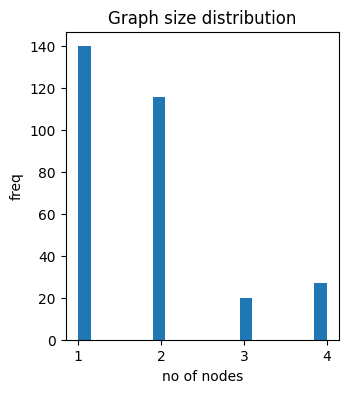

In [18]:
node_c = []
for idx in train_df['id']:
  A,X,y = load_graph(idx,is_train=True)
  node_c.append(A.shape[0])

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.hist(node_c,bins=20)
plt.xlabel('no of nodes')
plt.ylabel('freq')
plt.title("Graph size distribution")
plt.show()

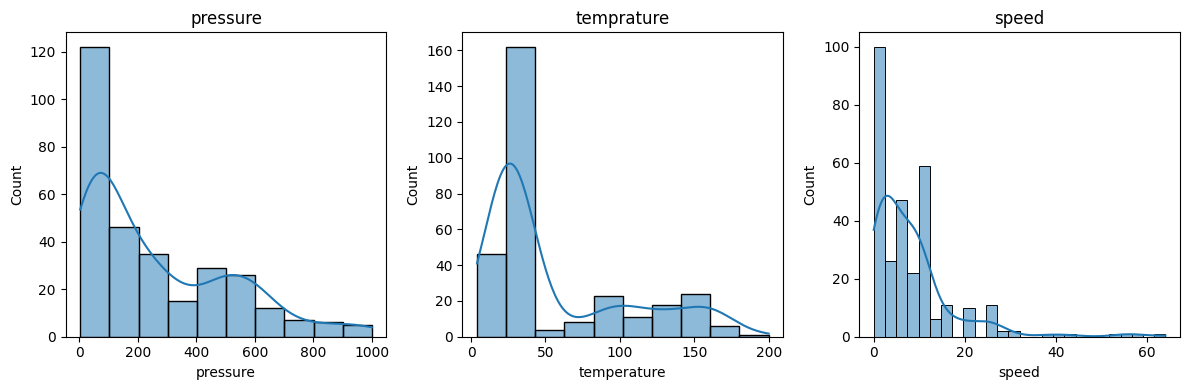

In [19]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
sns.histplot(train_df['pressure'],kde=True)
plt.title("pressure")



plt.subplot(1,3,2)
sns.histplot(train_df['temperature'],kde=True)
plt.title("temprature")

plt.subplot(1,3,3)
sns.histplot(train_df['speed'],kde=True)
plt.title("speed")

plt.tight_layout()
plt.show()

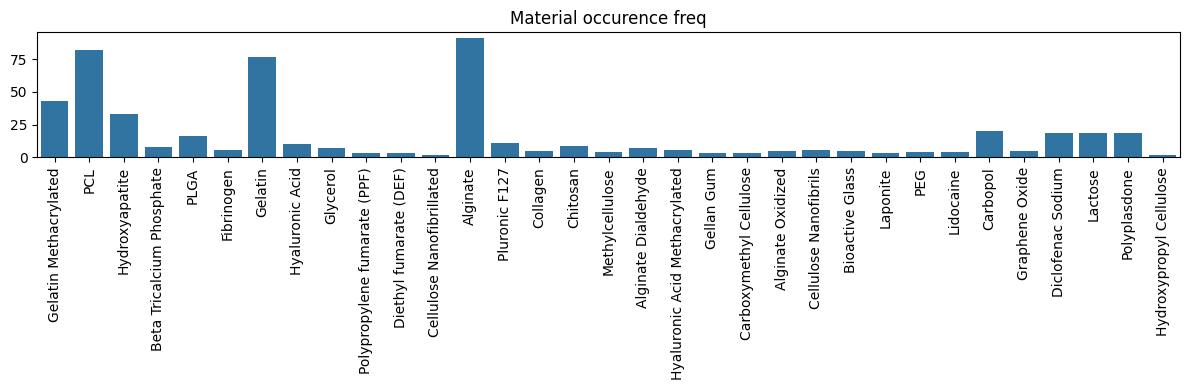

In [20]:
material_ctr = {}
for idx in train_df['id']:
  A,X,y = load_graph(idx,is_train=True)
  one_hot = X[:,:-1]
  material_indices = np.argmax(one_hot,axis=1)
  for m_idx in material_indices:
    material_ctr[m_idx] = material_ctr.get(m_idx,0)+1
material_names = [material_list[i] for i in material_ctr.keys()]
counts = list(material_ctr.values())
plt.figure(figsize=(12,4))
sns.barplot(x=material_names,y=counts)
plt.xticks(rotation=90)
plt.title("Material occurence freq")
plt.tight_layout()
plt.show()

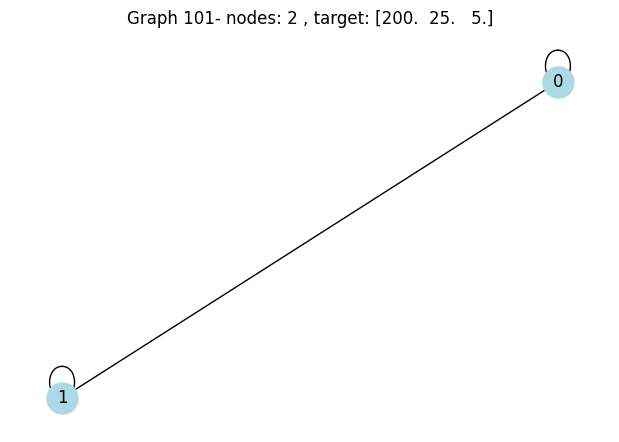

In [21]:
sample2node = train_df[train_df['id'].isin([101,102])].iloc[0]['id']
A,X,y = load_graph(sample2node,is_train=True)
edge_idx,i = dense_to_sparse(torch.tensor(A))
data = Data(x=torch.tensor(X),edge_index=edge_idx)
G = to_networkx(data,to_undirected=True)
pos = nx.spring_layout(G,seed=SEED)
plt.figure(figsize=(6,4))
nx.draw(G,pos,with_labels=True,node_color='lightblue',node_size=500)
plt.title(f"Graph {sample2node}- nodes: {A.shape[0]} , target: {y}")
plt.show()

In [22]:
def build_graph_data(graph_id, is_train=True):
  if is_train:
    A,X,y = load_graph(graph_id,is_train=True)
  else:
    A,X,_ = load_graph(graph_id, is_train=False)
  edge_index, _ = dense_to_sparse(torch.tensor(A,dtype=torch.float))
  edge_index = to_undirected(edge_index, num_nodes=A.shape[0])
  x =  torch.tensor(X,dtype=torch.float)
  if is_train:
    y = torch.tensor(y,dtype=torch.float)
  else:
    y = None
  return Data(x=x,edge_index=edge_index,y=y)

In [23]:
train_graphs = []
for idx in train_df['id']:
  data = build_graph_data(idx,is_train=True)
  data.id = idx
  train_graphs.append(data)

test_graphs = []
for idx in test_ids_df['id']:
  data = build_graph_data(idx,is_train=False)
  data.id  = idx
  test_graphs.append(data)


In [24]:
print(f'Built training graphs = {len(train_graphs)} test graphs = {len(test_graphs)} ')

Built training graphs = 303 test graphs = 120 


In [25]:
y_all = np.stack([g.y.numpy() for g in train_graphs])
pressure_bins = pd.cut(y_all[:,0],bins=5,labels=False)
train_idx, val_idx = train_test_split(
    np.arange(len(train_graphs)), test_size=0.2, random_state=SEED,
    stratify=pressure_bins
)

In [26]:
train_data = [train_graphs[i] for i in train_idx]
val_data = [train_graphs[i] for i in val_idx]
print(f"Training graphs = {len(train_data)} Validatiaon Graphs = {len(val_data)}")

Training graphs = 242 Validatiaon Graphs = 61


In [27]:
train_loader = DataLoader(train_data,batch_size=32,shuffle=True)
val_loader = DataLoader(val_data,batch_size=32,shuffle=False)
test_loader = DataLoader(test_graphs, batch_size=32, shuffle=False)

In [69]:
def nmae(y_true,y_pred):
  if y_true.ndim == 1:
    y_true=y_true.reshape(-1,3)
  if y_pred.ndim==1:
    y_pred=y_pred.reshape(-1,3)
  norm=np.array([1496.0,228.0,90.0])
  mae=np.mean(np.abs(y_true - y_pred),axis=0)
  return np.mean(mae/norm)

In [70]:
class GCN(nn.Module):
  def __init__(self,in_channels,hidden_channels,out_channels,num_layers,dropout):
    super().__init__()
    self.dropout = dropout
    self.convs = nn.ModuleList()
    self.bns=  nn.ModuleList()
    self.convs.append(GCNConv(in_channels,hidden_channels))
    self.bns.append(nn.BatchNorm1d(hidden_channels))

    for i in range(num_layers-1):
      self.convs.append(GCNConv(hidden_channels,hidden_channels))
      self.bns.append(nn.BatchNorm1d(hidden_channels))

    self.reg = nn.Sequential(
        nn.Linear(hidden_channels,hidden_channels//2),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(hidden_channels//2,out_channels)
    )
  def forward(self,data):
    x, edge_index, batch = data.x, data.edge_index, data.batch
    for i,conv in enumerate(self.convs):
      x = conv(x,edge_index)
      x = self.bns[i](x)
      x = F.relu(x)
      x = F.dropout(x,p=self.dropout,training=self.training)
    x = global_mean_pool(x,batch)
    return self.reg(x)

In [71]:
class SAGE(nn.Module):
  def __init__(self,in_channels,hidden_channels,out_channels,num_layers,dropout):
    super().__init__()
    self.dropout = dropout
    self.convs = nn.ModuleList()
    self.bns = nn.ModuleList()
    self.convs.append(SAGEConv(in_channels,hidden_channels))
    self.bns.append(nn.BatchNorm1d(hidden_channels))

    for i in range(num_layers - 1):
      self.convs.append(SAGEConv(hidden_channels, hidden_channels))
      self.bns.append(nn.BatchNorm1d(hidden_channels))

    self.reg = nn.Sequential(
        nn.Linear(hidden_channels,hidden_channels//2),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(hidden_channels//2,out_channels)
    )
  def forward(self,data):
    x,edge_index,batch = data.x, data.edge_index, data.batch
    for i,conv in enumerate(self.convs):
      x = conv(x,edge_index)
      x = self.bns[i](x)
      x = F.relu(x)
      x = F.dropout(x,p=self.dropout,training =self.training)
    x = global_mean_pool(x,batch)
    return self.reg(x)


In [95]:
class GAT(nn.Module):
  def __init__(self,in_channels, hidden_channels, out_channels,no_heads, num_layers,dropout):
    super().__init__()
    self.dropout = dropout
    self.convs = nn.ModuleList()
    self.bns = nn.ModuleList()
    self.convs.append(GATv2Conv(in_channels,hidden_channels,heads=no_heads, concat=True, dropout=dropout))
    self.bns.append(nn.BatchNorm1d(hidden_channels * no_heads))
    for i in range(num_layers-2):
      self.convs.append(GATv2Conv(hidden_channels * no_heads, hidden_channels,heads=no_heads,concat=True,dropout=dropout))
      self.bns.append(nn.BatchNorm1d(hidden_channels * no_heads))
    if num_layers > 1:
      self.convs.append(GATv2Conv(hidden_channels * no_heads, hidden_channels, heads=1, concat=False,dropout=dropout))
      f_ch = hidden_channels
    else:
      self.convs.append(GATv2Conv(in_channels, hidden_channels, heads=1, concat=False,dropout=dropout))
      f_ch=hidden_channels
    self.r = nn.Sequential(
        nn.Linear(f_ch, f_ch // 2),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(f_ch // 2,out_channels)
    )
  def forward(self,data):
    x,edge_index,batch = data.x, data.edge_index, data.batch
    for i,conv in enumerate(self.convs):
      x = conv(x,edge_index)
      if i < len(self.bns):
        x = self.bns[i](x)
      x = F.elu(x)
      x = F.dropout(x,p=self.dropout,training=self.training)
    x = global_mean_pool(x,batch)
    return self.r(x)


In [96]:
def train(model,loader, optimizer, criterion):
  model.train()
  total_loss =  0
  for data in loader:
    data = data.to(device)
    optimizer.zero_grad()
    out = model(data)
    target = data.y.view(-1,3)
    loss = criterion(out,target)
    loss.backward()
    optimizer.step()
    total_loss += loss.item() * data.num_graphs
  return total_loss / len(loader.dataset)

In [97]:
@torch.no_grad()
def eval(model,loader,criterion):
  model.eval()
  total_loss = 0
  all_preds = []
  all_targets = []
  for data in loader:
    data = data.to(device)
    out = model(data)
    loss=  criterion(out,data.y.view(-1,3))
    total_loss += loss.item() * data.num_graphs
    all_preds.append(out.cpu().numpy())
    all_targets.append(data.y.cpu().numpy())
  preds = np.concatenate(all_preds, axis=0)
  targets = np.concatenate(all_targets, axis=0)
  nmae_val = nmae(targets,preds)
  return total_loss / len(loader.dataset), nmae_val

In [98]:
def train_model(model,train_loader,val_loader,epochs,lr, weight_decay, patience):
  model = model.to(device)
  optimizer = torch.optim.Adam(model.parameters(),lr=lr,weight_decay = weight_decay)
  scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=epochs,eta_min=1e-5)
  criterion = nn.L1Loss()
  best_nmae=float('inf')
  best_state = None
  patience_ctr = 0
  history = {'train_loss':[],'val_nmae':[]}
  start_time = time.time()

  for epoch in range(1,epochs+1):
    train_loss = train(model,train_loader,optimizer,criterion)
    val_loss,val_nmae=  eval(model,val_loader, criterion)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_nmae'].append(val_nmae)

    if val_nmae < best_nmae:
      best_nmae = val_nmae
      best_state = copy.deepcopy(model.state_dict())
      patience_ctr = 0
    else:
      patience_ctr += 1
      if patience_ctr>= patience:
        print(f'Early stopping at epoch = {epoch}')

        break
    if epoch % 50 == 0:
      print(f"Epoch {epoch:.3f} | Train Loss: {train_loss:.4f} | Val NMAE = {val_nmae:.4f}")
  tot_time = time.time() - start_time
  model.load_state_dict(best_state)
  return model, best_nmae, history, tot_time



In [99]:
def plotter(hist):
  plt.figure(figsize=(15,5))
  plt.subplot(1,3,1)
  plt.plot(hist['train_loss'],label="Train Loss")
  plt.title('Train Loss')
  plt.xlabel("Epoch")
  plt.legend()

  plt.subplot(1,3,2)
  plt.plot(hist['val_nmae'],label="Val NMAE")
  plt.title("VAL NMAE")
  plt.xlabel("Epoch")
  plt.legend()
  plt.tight_layout()
  plt.show()

In [108]:
in_channels = train_graphs[0].x.shape[1]
out_channels = 3
hps = []
run_id = 0

In [109]:
print("GCN")
model_gcn = GCN(in_channels=in_channels,hidden_channels = 64,out_channels=out_channels,num_layers=2,dropout=0.5)
best_model_gcn,best_nmae_gcn, hist_gcn, t_gcn = train_model(model_gcn,train_loader, val_loader, epochs=300,lr=0.001,weight_decay=1e-3,patience=40)
hps.append({'run': run_id+1, 'arch': 'GCN', 'hidden': 64, 'layers': 2, 'NMAE': best_nmae_gcn, 'time_sec': t_gcn})
run_id += 1

GCN
Epoch 50.000 | Train Loss: 58.3739 | Val NMAE = 0.0771
Epoch 100.000 | Train Loss: 51.1369 | Val NMAE = 0.0758
Early stopping at epoch = 125


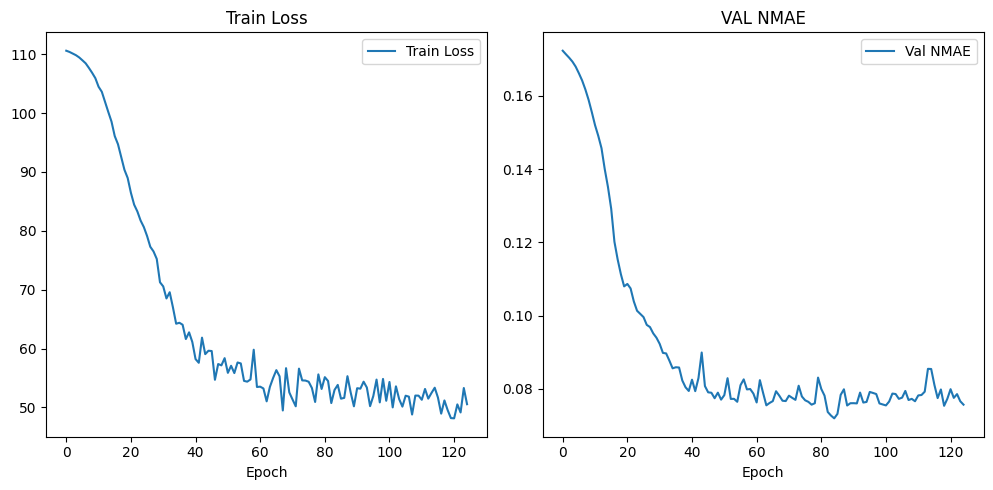

In [110]:
plotter(hist_gcn)

In [111]:
print("GraphSAGE")
model_sage = SAGE(in_channels=in_channels,hidden_channels = 64,out_channels=out_channels,num_layers=2,dropout=0.5)
best_model_sage,best_nmae_sage, hist_sage, t_sage = train_model(model_sage,train_loader, val_loader,epochs=300,lr=0.01,weight_decay=5e-4,patience=40)
hps.append({'run': run_id+1, 'arch': 'GraphSAGE', 'hidden': 64, 'layers': 2, 'NMAE': best_nmae_sage, 'time_sec': t_sage})
run_id += 1

GraphSAGE
Epoch 50.000 | Train Loss: 52.0429 | Val NMAE = 0.0744
Early stopping at epoch = 72


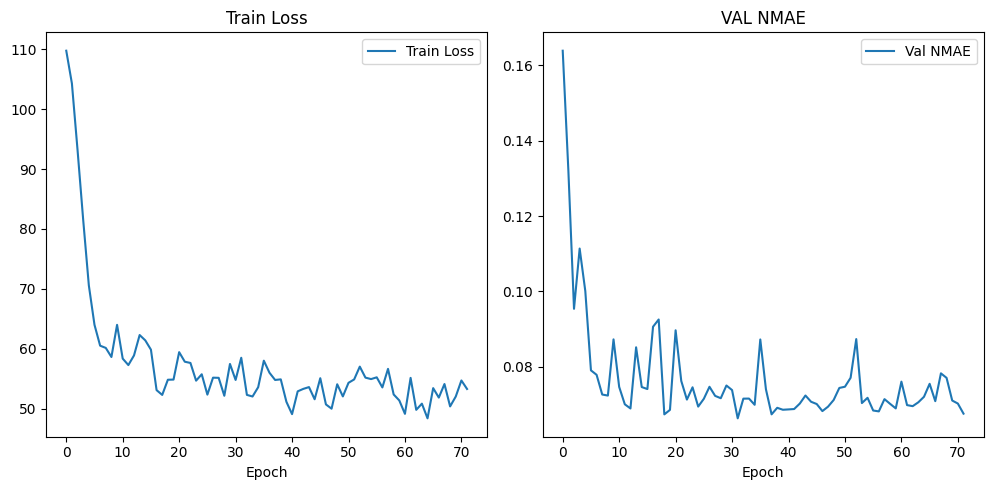

In [112]:
plotter(hist_sage)

In [113]:
print("GAT")
model_gat = GAT(in_channels=in_channels,hidden_channels = 64,out_channels=out_channels,num_layers=2,no_heads=4,dropout=0.5)
best_model_gat, best_nmae_gat, hist_gat, t_gat = train_model(model_gat,train_loader, val_loader, epochs=500, lr=0.001, weight_decay=5e-3, patience=40)
hps.append({'run': run_id+1, 'arch': 'GAT', 'hidden': 64, 'heads': 4, 'layers': 2, 'NMAE': best_nmae_gat, 'time_sec': t_gat})
run_id += 1

GAT
Epoch 50.000 | Train Loss: 75.5829 | Val NMAE = 0.1055
Epoch 100.000 | Train Loss: 72.7058 | Val NMAE = 0.1007
Epoch 150.000 | Train Loss: 71.1823 | Val NMAE = 0.0992
Early stopping at epoch = 161


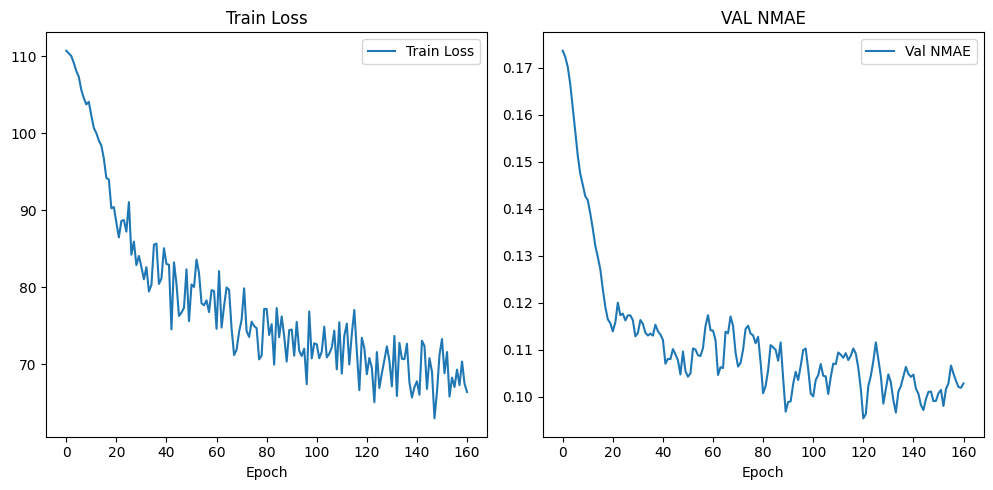

In [114]:
plotter(hist_gat)

In [115]:
print("GraphSAGE v2")
model_sage_v2 = SAGE(in_channels=in_channels,hidden_channels = 128,out_channels=out_channels,num_layers=3,dropout=0.5)
best_model_sage_v2,best_nmae_sage_v2, hist_sage_v2, t_sage_v2 = train_model(model_sage_v2,train_loader, val_loader,epochs=300,lr=0.01,weight_decay=5e-4,patience=40)
hps.append({'run': run_id+1, 'arch': 'GraphSAGE v2', 'hidden': 128, 'layers': 3, 'NMAE': best_nmae_sage_v2, 'time_sec': t_sage_v2})
run_id += 1

GraphSAGE v2
Epoch 50.000 | Train Loss: 48.2929 | Val NMAE = 0.0702
Early stopping at epoch = 65


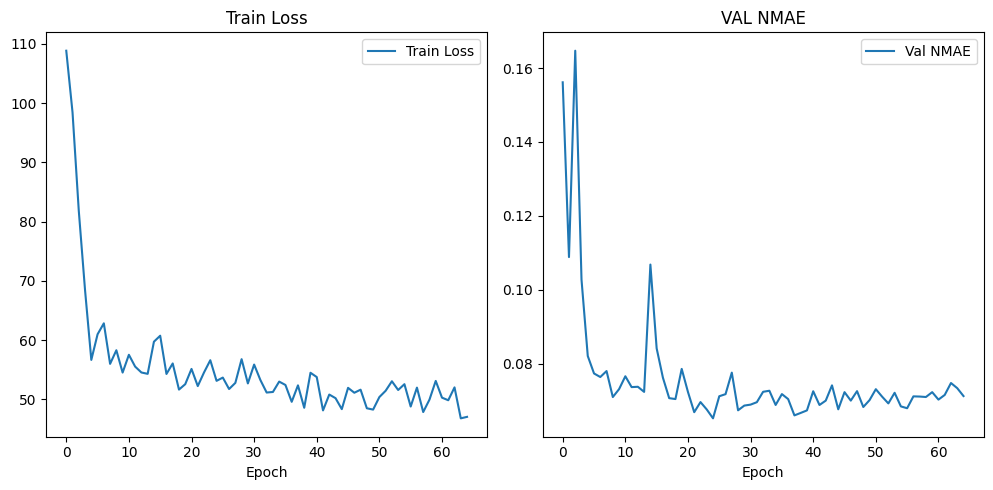

In [116]:
plotter(hist_sage_v2)

In [117]:
print("GraphSAGE v3")
model_sage_v3 = SAGE(in_channels=in_channels,hidden_channels = 256,out_channels=out_channels,num_layers=3,dropout=0.5)
best_model_sage_v3,best_nmae_sage_v3, hist_sage_v3, t_sage_v3 = train_model(model_sage_v3,train_loader, val_loader,epochs=300,lr=0.01,weight_decay=5e-4,patience=40)
hps.append({'run': run_id+1, 'arch': 'GraphSAGE v3', 'hidden': 256, 'layers': 3, 'NMAE': best_nmae_sage_v3, 'time_sec': t_sage_v3})
run_id += 1

GraphSAGE v3
Epoch 50.000 | Train Loss: 47.1572 | Val NMAE = 0.0730
Early stopping at epoch = 96


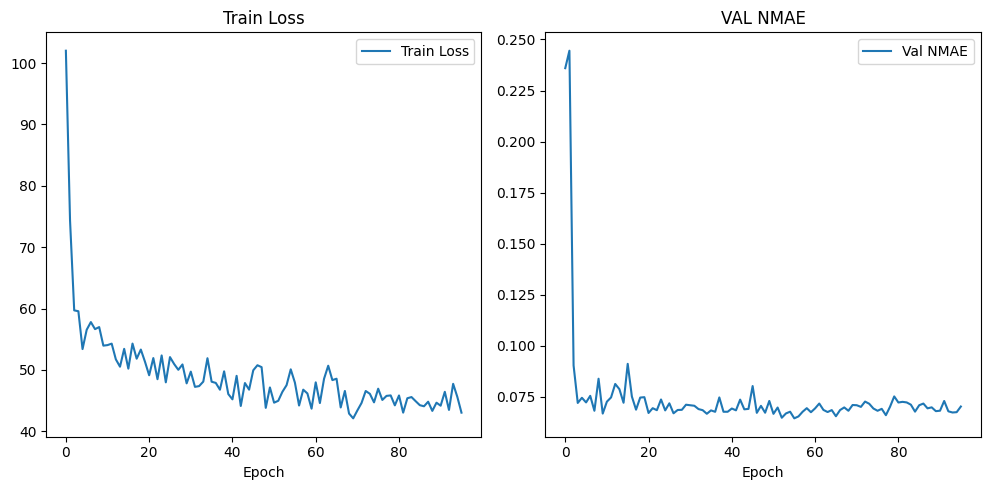

In [118]:
plotter(hist_sage_v3)

In [119]:
pd.DataFrame(hps)

,run,arch,hidden,layers,NMAE,time_sec,heads
0,1,GCN,64,2,0.071976,8.831032,NaN
1,2,GraphSAGE,64,2,0.066360,4.103415,NaN
2,3,GAT,64,2,0.095452,15.121169,4.0
3,4,GraphSAGE v2,128,3,0.065250,5.971992,NaN
4,5,GraphSAGE v3,256,3,0.064528,11.607627,NaN


# Submission

In [120]:
model_sage_v3.eval()
all_predictions = []
with torch.no_grad():
    for data in test_loader:
        data = data.to(device)
        out = model_sage_v3(data)
        all_predictions.append(out.cpu().numpy())
predictions = np.concatenate(all_predictions, axis=0)

In [121]:
submission = pd.DataFrame({
    'id': test_ids_df['id'].values,
    'pressure': predictions[:, 0],
    'temperature': predictions[:, 1],
    'speed': predictions[:, 2]
})

In [123]:
submission.head()

,id,pressure,temperature,speed
0,4,79.883270,19.872696,5.821636
1,5,79.883270,19.872696,5.821636
2,6,502.435181,106.330795,1.097063
3,34,84.059204,19.038357,4.012270
4,35,86.003609,19.497223,3.913458


In [124]:
submission.to_csv('predictions.csv', index=False)

In [127]:
torch.save(model_sage_v3.state_dict(),'best_sage_model.pt')

In [126]:
END_TIME = time.time() - START_TIME
hours = END_TIME / 3600
print(f"{hours:.2f} hrs")

1.01 hrs
